In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [2]:
dataset = pd.read_csv('vol.csv')
dataset.head()

,Mixture Type,Aggregate Source,Softening Point,DAG (m²/kg),Compaction (blows),Gmb,Air Voids (%),VMA (%),VFB (%)
0,1,2.72,51.1,5.58,35,2.353,7.243,18.011,59.787
1,1,2.72,51.1,5.58,50,2.375,5.982,16.897,64.597
2,1,2.72,51.1,5.58,75,2.425,4.003,15.148,73.576
3,1,2.72,51.1,5.58,90,2.439,3.449,14.658,76.475
4,1,2.72,51.1,5.58,110,2.442,3.262,14.493,77.492


In [3]:
X = dataset.iloc[:, 0:5]
y = dataset.iloc[:,6]
X0= dataset.iloc[:,0]
X1= dataset.iloc[:,1]
X2= dataset.iloc[:,2]
X3= dataset.iloc[:,3]

In [4]:
X

,Mixture Type,Aggregate Source,Softening Point,DAG (m²/kg),Compaction (blows)
0,1,2.72,51.1,5.58,35
1,1,2.72,51.1,5.58,50
2,1,2.72,51.1,5.58,75
3,1,2.72,51.1,5.58,90
4,1,2.72,51.1,5.58,110
...,...,...,...,...,...
445,3,2.55,79.6,9.54,25
446,3,2.55,79.6,9.54,35
447,3,2.55,79.6,9.54,50
448,3,2.55,79.6,9.54,75


In [5]:
y

0      7.243
1      5.982
2      4.003
3      3.449
4      3.262
       ...  
445    6.914
446    5.811
447    4.107
448    3.859
449    2.767
Name: Air Voids (%), Length: 450, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
regressor = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

In [8]:

regressor.fit(X_train, y_train)

GradientBoostingRegressor(max_features='sqrt', n_estimators=500,
                          random_state=42, subsample=0.8)

In [9]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)

In [10]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.21208352365478308


In [11]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.905400793932944

In [12]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]  # Removed 'auto' to avoid warning
}

In [13]:
grid_search = GridSearchCV(estimator=regressor, param_grid=param_grid,
                           cv=5, scoring='r2', n_jobs=1, verbose=2)


In [14]:
# grid_search.fit(X_train, y_train)

In [15]:
# print("Best Parameters:", grid_search.best_params_)

In [16]:
regressor.predict([
    [2, 2.72, 78.7, 4.75, 50],
    [2, 2.72, 71.6, 4.71, 50],
    [3, 2.72, 86.3, 8.56, 50],
    [2, 2.55, 71.6, 4.9, 50],
    [2, 2.55, 78.7, 5.99, 110],
    [1, 2.72, 71.6, 5.32, 110],
    [3, 2.55, 71.6, 8.12, 50],
    [3, 2.55, 78.7, 7.02, 75],
    [2, 2.72, 86.3, 5.82, 90],
    [1, 2.55, 78.7, 5.05, 50],
    [2, 2.55, 71.6, 5.37, 50],
    [2, 2.55, 86.3, 5.37, 35],
    [2, 2.72, 71.6, 5.27, 75],
    [3, 2.55, 86.3, 7.02, 50],
    [2, 2.72, 86.3, 5.27, 90],
    [3, 2.72, 86.3, 8.63, 25],
    [2, 2.72, 71.6, 5.79, 50],
    [2, 2.55, 86.3, 5.93, 35],
    [1, 2.72, 71.6, 6.48, 75],
    [1, 2.55, 86.3, 6.16, 35],
    [2, 2.55, 71.6, 5.37, 90],
    [2, 2.55, 71.6, 4.84, 35],
    [3, 2.72, 71.6, 8.56, 90],
    [1, 2.55, 71.6, 5.05, 75],
    [3, 2.55, 78.7, 8.12, 75],
    [1, 2.72, 86.3, 5.89, 75],
    [2, 2.72, 86.3, 4.71, 50],
    [2, 2.55, 86.3, 4.84, 35],
    [1, 2.55, 86.3, 5.11, 110],
    [2, 2.55, 78.7, 5.99, 90],
    [3, 2.72, 86.3, 8.56, 75],
    [1, 2.55, 71.6, 5.05, 35],
    [1, 2.72, 86.3, 5.27, 35],
    [1, 2.72, 86.3, 5.32, 35],
    [1, 2.55, 71.6, 5.11, 90],
    [1, 2.55, 71.6, 6.16, 75],
    [2, 2.55, 86.3, 4.9, 110],
    [2, 2.72, 71.6, 5.79, 90],
    [1, 2.55, 78.7, 5.58, 75],
    [3, 2.55, 86.3, 7.02, 25],
    [3, 2.55, 86.3, 7.06, 90],
    [1, 2.55, 78.7, 6.23, 35],
    [1, 2.72, 78.7, 5.89, 35],
    [1, 2.55, 71.6, 6.16, 50],
    [3, 2.72, 78.7, 8.63, 75],
    [2, 2.55, 71.6, 5.99, 75],
    [3, 2.55, 71.6, 9.56, 35],
    [1, 2.55, 71.6, 6.23, 50],
    [2, 2.55, 86.3, 5.93, 110],
    [2, 2.55, 78.7, 5.37, 50],
    [3, 2.72, 71.6, 8.63, 90],
    [3, 2.55, 86.3, 9.54, 35],
    [1, 2.55, 86.3, 5.58, 110],
    [1, 2.72, 71.6, 5.27, 90],
    [3, 2.72, 86.3, 7.73, 75],
    [3, 2.55, 71.6, 8.12, 25],
    [3, 2.72, 78.7, 8.63, 25],
    [1, 2.72, 71.6, 6.48, 35],
    [1, 2.55, 86.3, 5.58, 35],
    [3, 2.72, 78.7, 8.63, 90],
    [2, 2.55, 86.3, 5.37, 90],
    [3, 2.72, 86.3, 7.39, 35],
    [1, 2.55, 78.7, 6.23, 75],
    [3, 2.72, 86.3, 8.56, 90],
    [1, 2.72, 71.6, 5.27, 75],
    [1, 2.72, 78.7, 5.27, 50],
    [3, 2.72, 78.7, 8.63, 50],
    [1, 2.55, 78.7, 5.58, 50],
    [3, 2.55, 86.3, 8.12, 25],
    [3, 2.55, 71.6, 7.06, 90],
    [1, 2.55, 78.7, 6.23, 110],
    [1, 2.55, 86.3, 5.58, 90],
    [3, 2.55, 78.7, 9.56, 50],
    [1, 2.72, 86.3, 5.89, 50],
    [3, 2.72, 86.3, 8.63, 90],
    [1, 2.72, 86.3, 6.5, 110],
    [1, 2.55, 86.3, 5.05, 90],
    [2, 2.72, 86.3, 4.71, 35],
    [3, 2.55, 71.6, 9.56, 50],
    [2, 2.72, 71.6, 5.82, 110],
    [2, 2.55, 71.6, 5.99, 90],
    [2, 2.55, 71.6, 4.84, 50],
    [1, 2.72, 71.6, 5.32, 75],
    [1, 2.72, 78.7, 6.5, 75],
    [1, 2.55, 71.6, 5.05, 90],
    [3, 2.55, 86.3, 8.12, 35],
    [2, 2.55, 78.7, 4.84, 110],
    [2, 2.72, 78.7, 5.27, 50],
    [1, 2.55, 86.3, 5.11, 90],
    [3, 2.72, 86.3, 7.78, 75]
]
)

c:\Users\hp\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([5.15, 5.12, 4.08, 5.42, 3.16, 3.01, 4.08, 3.69, 3.38, 5.46, 4.83,
       6.26, 3.78, 4.05, 3.21, 6.97, 5.24, 6.32, 3.91, 7.24, 3.05, 6.92,
       2.87, 4.18, 3.72, 4.05, 5.12, 6.92, 2.72, 3.65, 3.71, 6.98, 6.57,
       6.74, 3.63, 4.21, 3.04, 3.37, 3.91, 6.87, 2.82, 7.  , 6.87, 5.83,
       3.72, 4.33, 5.78, 5.58, 4.39, 4.83, 2.86, 5.79, 2.52, 3.27, 3.66,
       6.96, 6.97, 6.78, 6.84, 2.86, 3.05, 5.69, 4.01, 2.87, 3.72, 5.09,
       4.08, 5.45, 6.96, 2.82, 2.79, 3.47, 4.13, 5.6 , 2.86, 3.31, 3.72,
       6.81, 4.13, 3.49, 3.65, 5.28, 3.7 , 3.96, 3.72, 5.77, 2.85, 5.  ,
       3.63, 3.68])

In [17]:
import pickle
with open('AV_sp.pkl', 'wb') as f:
    pickle.dump(regressor, f)

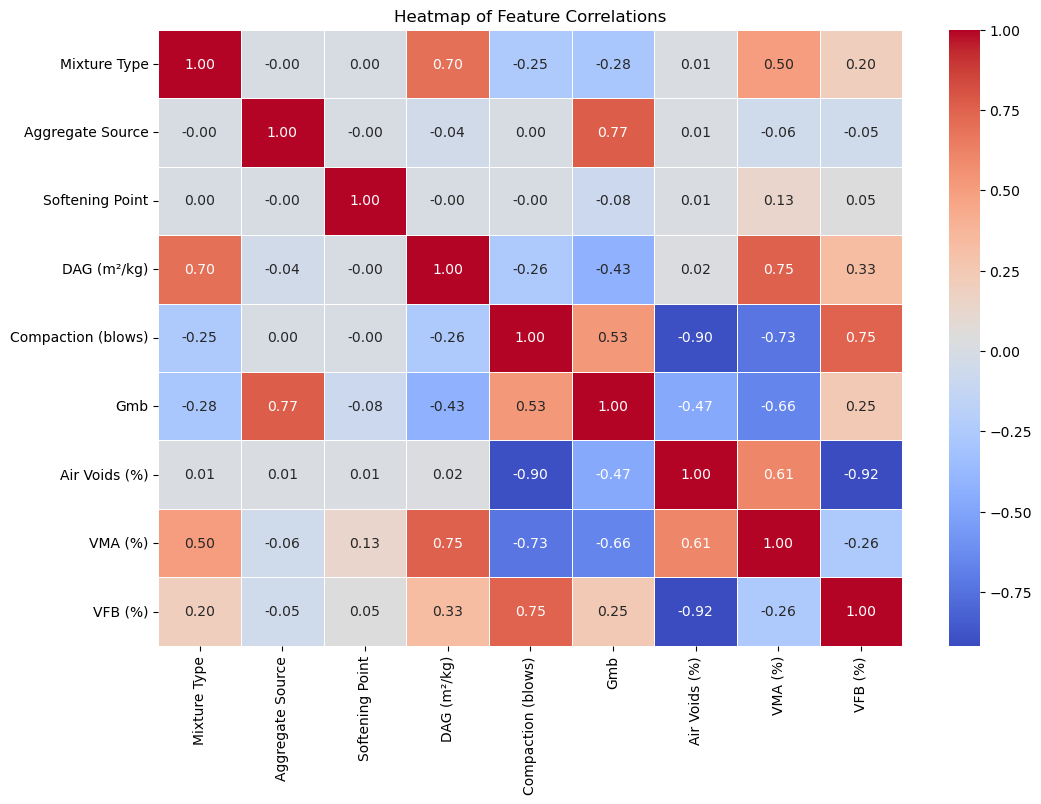

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix =dataset.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Feature Correlations")
plt.show()


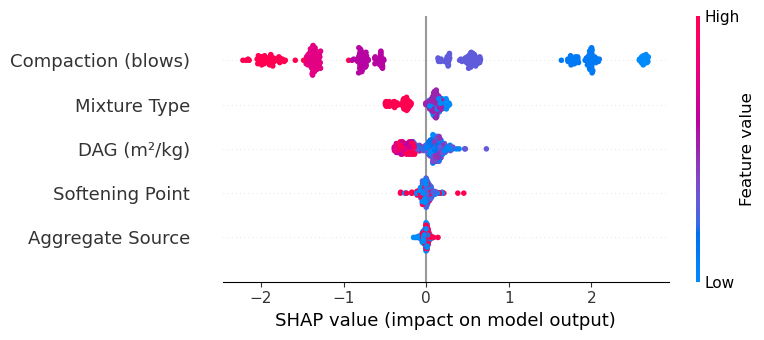

In [19]:

import shap

# Create SHAP explainer and compute values
explainer = shap.Explainer(regressor, X_train)
shap_values = explainer(X_train)

# Plot SHAP summary
shap.summary_plot(shap_values, X_train)


